# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

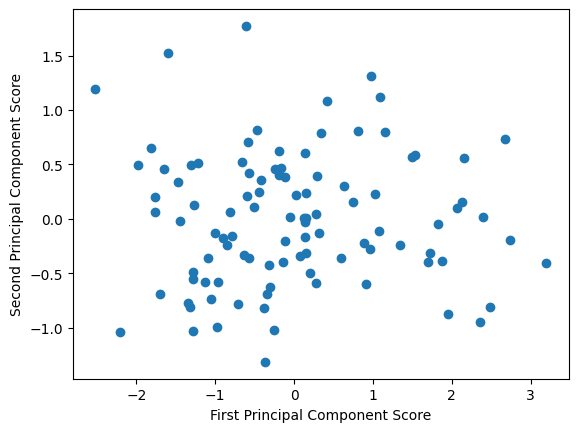

In [103]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

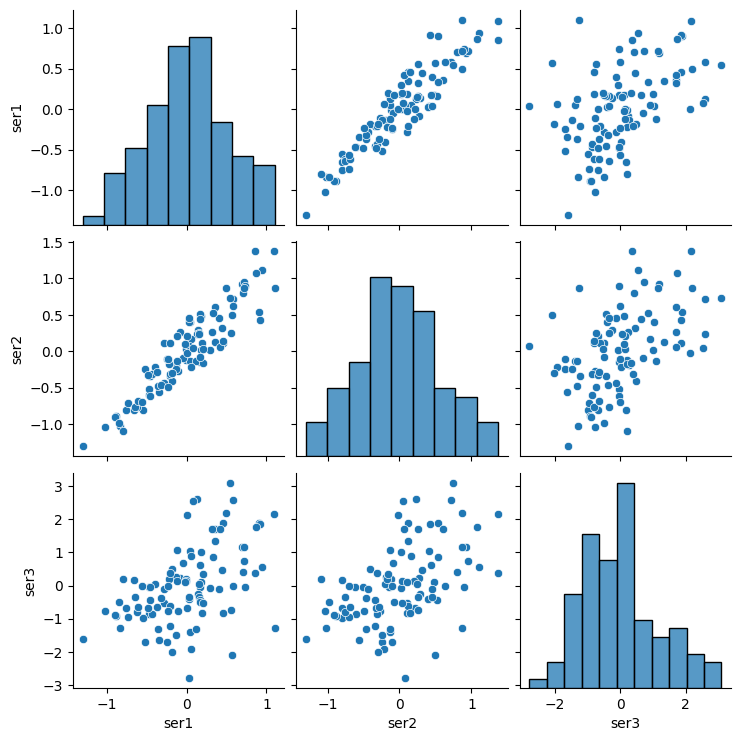

In [104]:
import seaborn as sns

# Create the pairplot
sns.pairplot(df)
plt.show()

**What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?**  

The outliers in the upper-left corner of the scatter plot have **low first principal component scores** (PC1) and **high second principal component scores** (PC2). This suggests they have lower values in `series_1` and `series_2`, but higher values in `series_3`.

**What does that mean about their values in series_1, series_2, and series_3?**

This suggests they have lower values in `series_1` and `series_2`, but higher values in `series_3`, as series_3` has a strong contribution to PC1.

 **It seems to me that you can say something about series_3 (what can you say?)**

 series_3 has a large contribution to the first principal component (PC1), meaning it has the greatest influence on the variance in the data, especially for the outliers.

 **But you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?**  

 series_1 and series_2 are correlated since series_2 is derived from series_1. This makes it difficult to distinguish them in the first principal component.

 **How are series_1 and series_2 related, according to how they were created?**

 series_2 is a modified version of series_1, with added noise and scaling, making them correlated, as evidenced in the pairplot.

**Overall, what are the advantages and disadvantages of the graph?  Does it show anything interesting?**

-Advantages:
The PCA graph reduces dimensionality,we can see outliers, and provides a visual representation of the variance in the data.

-Disadvantages:
The graph doesn't show individual relationships between series_1, series_2, and series_3 directly and may obscure their correlation, especially between series_1 and series_2.

-Does the graph show anything interesting?
Yes, the graph reveals the outliers and provides insight into the overall variance in the data, although more detailed analysis is needed for deeper interpretation.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Dataset 1: Web page Phishing Detection Dataset

In [105]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/web-page-phishing-detection-dataset/versions/2


In [106]:
# import pandas as pd

# Load the dataset
dataset1 = pd.read_csv(path + '/dataset_phishing.csv')

# Display the first few rows of the dataset
print(dataset1.head())

                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                0                

In [107]:
dataset1.nunique().sort_values(ascending=False).head()

,0
url,11429
web_traffic,4744
domain_age,4430
ratio_intHyperlinks,3131
ratio_extHyperlinks,3131


In [108]:
dataset1.nunique().sort_values(ascending=False).tail()

,0
sfh,1
ratio_nullHyperlinks,1
submit_email,1
ratio_intRedirection,1
ratio_intErrors,1


In [109]:
# change status into int dtype with legitimate as 0 and phishing as 1
mapping = {'legitimate':0, 'phishing':1}

dataset1['status'] = dataset1['status'].map(mapping)

In [110]:
dataset1['status'].isna().sum()

np.int64(0)

In [111]:
df1_corr_matrix = dataset1.corr(numeric_only=True)
df1_corr_matrix

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
length_url,1.000000,0.223025,0.453961,0.443589,0.399564,0.150739,0.520930,0.576268,NaN,0.621745,...,0.125159,-0.006476,-0.007082,0.002799,-0.006798,0.072205,0.023357,0.236395,-0.102582,0.248580
length_hostname,0.223025,1.000000,0.252013,0.408956,0.057702,0.071793,0.162400,0.145617,NaN,0.183405,...,0.217284,0.074707,-0.097794,-0.041081,0.013854,0.163238,-0.023344,0.213990,-0.159342,0.238322
ip,0.453961,0.252013,1.000000,0.288398,0.109860,0.059401,0.405434,0.383262,NaN,0.440972,...,0.137716,0.014561,0.053246,-0.108869,-0.077020,0.167930,0.127823,0.270743,-0.218968,0.321698
nb_dots,0.443589,0.408956,0.288398,1.000000,0.045099,0.263283,0.347411,0.435798,NaN,0.414902,...,0.107789,0.055560,0.056407,-0.024117,-0.007818,0.087969,0.126659,0.209616,-0.097312,0.207029
nb_hyphens,0.399564,0.057702,0.109860,0.045099,1.000000,0.018770,0.036804,0.120487,NaN,0.107050,...,0.006909,0.020297,-0.055794,0.038163,0.080104,-0.041464,-0.031477,-0.018828,0.104341,-0.100107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
web_traffic,0.072205,0.163238,0.167930,0.087969,-0.041464,-0.009459,0.143777,0.164797,NaN,0.187809,...,0.081786,0.083888,0.022598,-0.110435,-0.096698,1.000000,-0.007113,0.034099,-0.209526,0.060388
dns_record,0.023357,-0.023344,0.127823,0.126659,-0.031477,0.031611,0.009441,0.076372,NaN,0.052159,...,0.062084,0.043817,0.213899,-0.060811,-0.068023,-0.007113,1.000000,0.096413,-0.142135,0.122119
google_index,0.236395,0.213990,0.270743,0.209616,-0.018828,0.113217,0.201260,0.129093,NaN,0.167385,...,0.267465,-0.143655,0.040633,-0.134656,-0.210111,0.034099,0.096413,1.000000,-0.389887,0.731171
page_rank,-0.102582,-0.159342,-0.218968,-0.097312,0.104341,-0.066356,-0.123852,-0.126164,NaN,-0.133089,...,-0.330810,0.058843,-0.155990,0.345751,0.589602,-0.209526,-0.142135,-0.389887,1.000000,-0.511137


In [112]:
df1_target_corr = df1_corr_matrix['status']
df1_target_corr.sort_values(ascending=False).head(10)

,status
status,1.000000
google_index,0.731171
ratio_digits_url,0.356395
domain_in_title,0.342807
phish_hints,0.335393
ip,0.321698
nb_qm,0.294319
length_url,0.248580
nb_slash,0.242270
length_hostname,0.238322


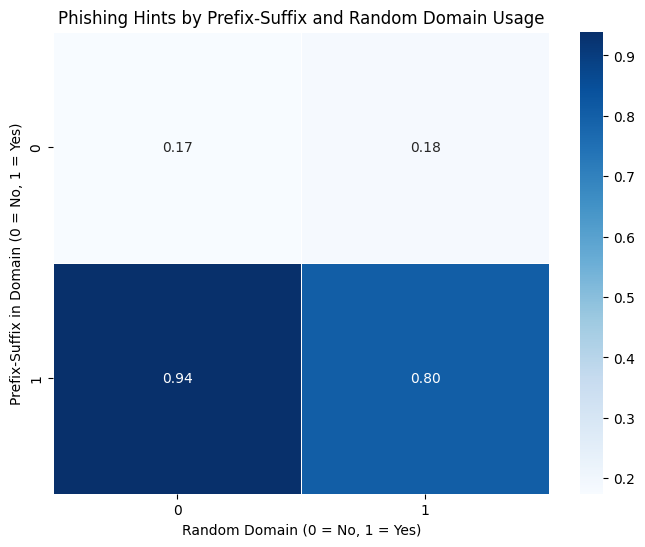

In [113]:
# Make a copy to avoid modifying the original
df1_heatmap = dataset1.copy()

# Pivot the table
pivot = df1_heatmap.pivot_table(
    index='prefix_suffix',
    columns='random_domain',
    values='phish_hints',
    aggfunc='mean'  # Could also use 'sum' or 'median'
)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Phishing Hints by Prefix-Suffix and Random Domain Usage")
plt.xlabel("Random Domain (0 = No, 1 = Yes)")
plt.ylabel("Prefix-Suffix in Domain (0 = No, 1 = Yes)")
plt.show()

<ipython-input-114-91920214b8a7>:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_h = dataset1.pivot_table(index='domain_in_brand', columns='google_index_binned', values='status', aggfunc='mean')


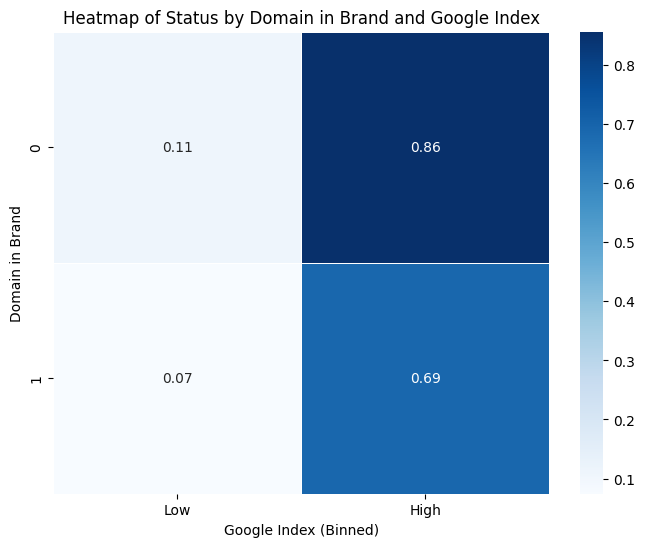

In [114]:
# Mapping for 'status' is already done

# Bin the google_index column (if it has continuous values)
dataset1['google_index_binned'] = pd.cut(dataset1['google_index'], bins=2, labels=["Low", "High"])

# Create pivot table
pivot_h = dataset1.pivot_table(index='domain_in_brand', columns='google_index_binned', values='status', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_h, cmap="Blues", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Status by Domain in Brand and Google Index")
plt.xlabel("Google Index (Binned)")
plt.ylabel("Domain in Brand")
plt.show()

<ipython-input-115-42205e2c93ba>:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_i = dataset1.pivot_table(index='abnormal_subdomain', columns='nb_slash_binned', values='phish_hints', aggfunc='mean')


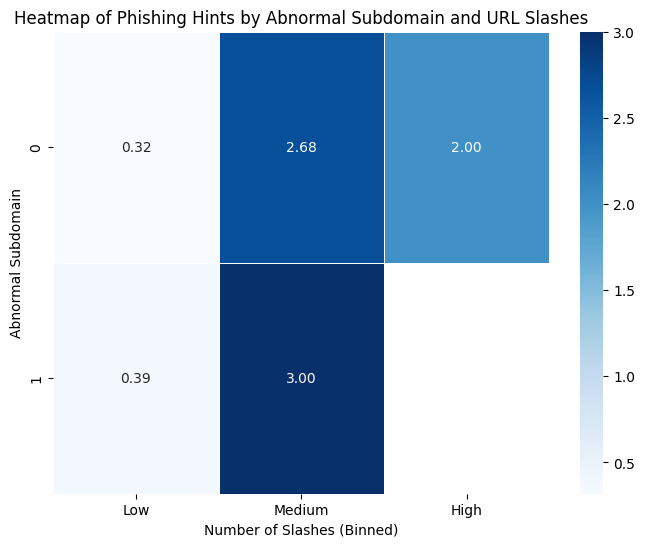

In [115]:
# Mapping for 'status' is already done

# Bin the nb_slash column (to group the number of slashes into 3 categories)
dataset1['nb_slash_binned'] = pd.cut(dataset1['nb_slash'], bins=3, labels=["Low", "Medium", "High"])

# Create pivot table
pivot_i = dataset1.pivot_table(index='abnormal_subdomain', columns='nb_slash_binned', values='phish_hints', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_i, cmap="Blues", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Phishing Hints by Abnormal Subdomain and URL Slashes")
plt.xlabel("Number of Slashes (Binned)")
plt.ylabel("Abnormal Subdomain")
plt.show()

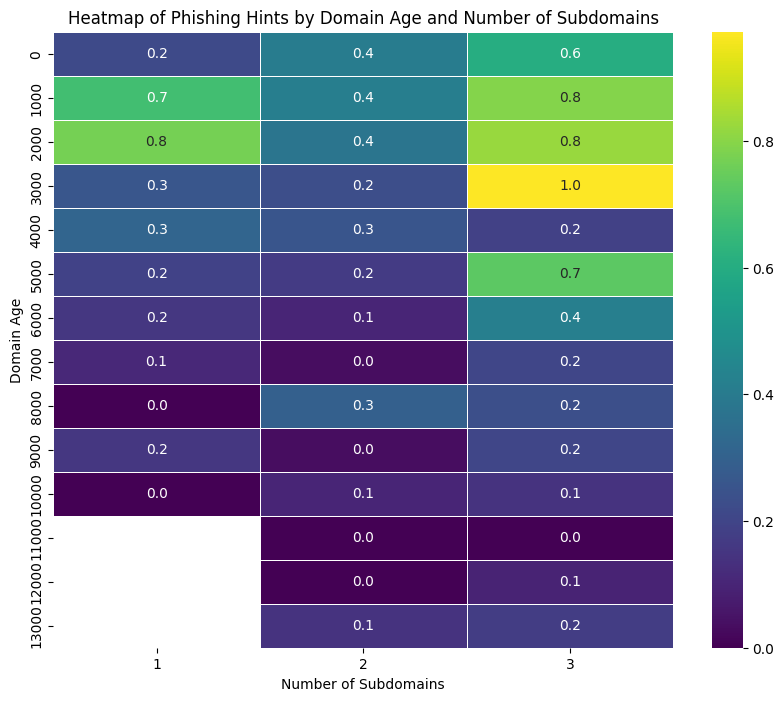

In [116]:
df1_heatmap['domain_age_binned'] = np.round(df1_heatmap['domain_age'], -3)  # Bin domain_age
df1_heatmap['nb_subdomains_binned'] = np.round(df1_heatmap['nb_subdomains'], 0)  # Bin subdomains

# Pivot table to create the heatmap
pivot1 = df1_heatmap.pivot_table(
    index='domain_age_binned',  # Use binned domain age
    columns='nb_subdomains_binned',  # Use binned number of subdomains
    values='phish_hints',  # Phishing hints
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot1, cmap='viridis', annot=True, fmt=".1f", linewidths=0.5)
plt.title("Heatmap of Phishing Hints by Domain Age and Number of Subdomains")
plt.xlabel("Number of Subdomains")
plt.ylabel("Domain Age")
plt.show()

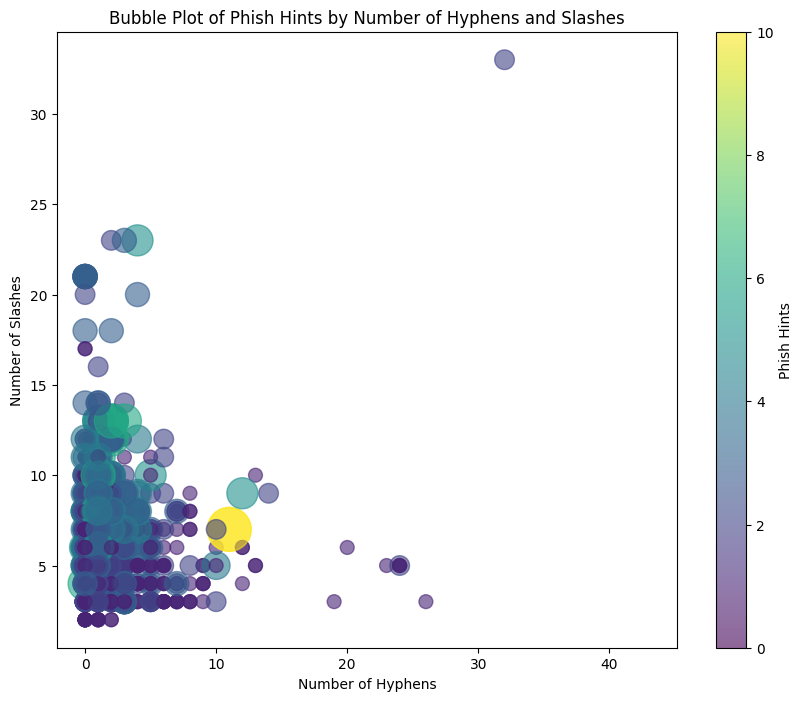

In [117]:
df1_bubble = dataset1.copy()

# Scatter plot with bubble size based on phish_hints
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df1_bubble["nb_hyphens"],  # X-axis: Number of Hyphens
    df1_bubble["nb_slash"],  # Y-axis: Number of Slashes
    s=df1_bubble["phish_hints"] * 100,  # Size bubbles based on phish_hints (scaled)
    c=df1_bubble["phish_hints"],  # Color bubbles by phish_hints
    cmap='viridis',  # Color map for phish_hints
    alpha=0.6  # Transparency of the bubbles
)

# Add color bar to represent phish_hints values
plt.colorbar(scatter, label='Phish Hints')

# Adding labels and title
plt.xlabel("Number of Hyphens")
plt.ylabel("Number of Slashes")
plt.title("Bubble Plot of Phish Hints by Number of Hyphens and Slashes")

# Show the plot
plt.show()

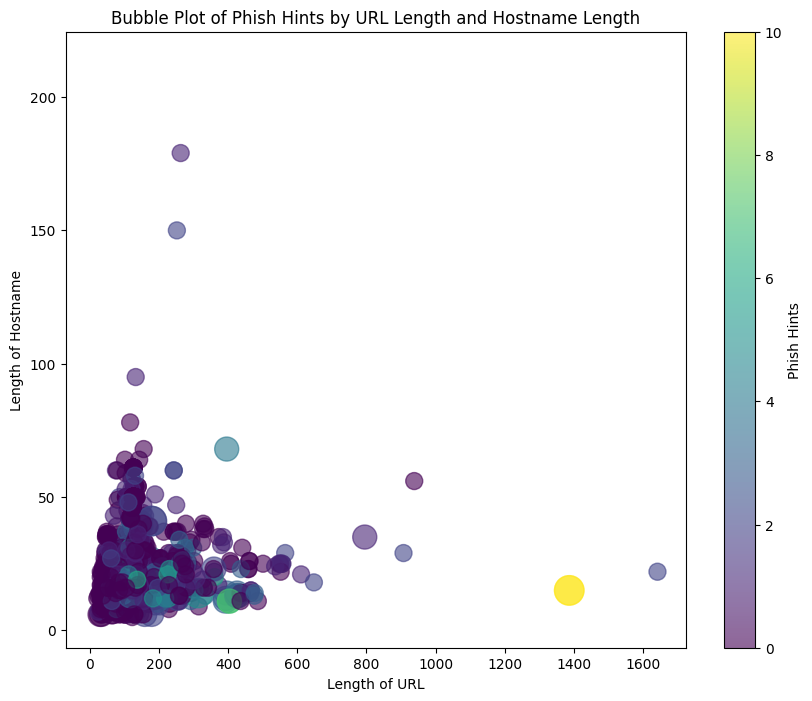

In [118]:
plt.figure(figsize=(10, 8))
scatter2 = plt.scatter(
    df1_bubble["length_url"],  # X-axis: Length of URL
    df1_bubble["length_hostname"],  # Y-axis: Length of Hostname
    s=df1_bubble["nb_qm"] * 150,  # Size bubbles based on number of question marks (scaled)
    c=df1_bubble["phish_hints"],  # Color bubbles by phish_hints
    cmap='viridis',  # Color map for phish_hints
    alpha=0.6  # Transparency of the bubbles
)

# Add color bar to represent phish_hints values
plt.colorbar(scatter2, label='Phish Hints')

# Adding labels and title
plt.xlabel("Length of URL")
plt.ylabel("Length of Hostname")
plt.title("Bubble Plot of Phish Hints by URL Length and Hostname Length")

# Show the plot
plt.show()

In [154]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [120]:
dataset1.isna().sum()

,0
url,0
length_url,0
length_hostname,0
ip,0
nb_dots,0
...,...
google_index,0
page_rank,0
status,0
google_index_binned,0


In [129]:
features = dataset1.drop(columns=['status'])  # exclude target
features = features.select_dtypes(include=[np.number])  # use only numeric features
#features = features.dropna(axis=1)  # drop any columns with NaNs

In [130]:
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

In [131]:
# Apply PCA
pca = PCA(n_components=None)
pca_components = pca.fit_transform(scaled_features)

In [132]:
# Variance explained by each component
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

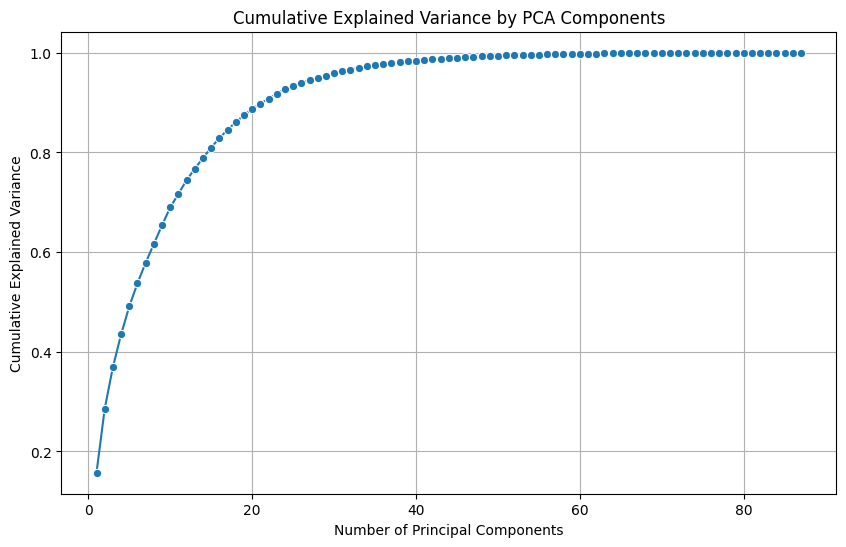

In [133]:
# Plot cumulative variance to see how many components are needed
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(cumulative_variance)+1), y=cumulative_variance, marker="o")
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [134]:
# First principal component (projection)
first_pc = pca_components[:, 0]

In [140]:
print(f"First principal component captures {explained_variance[0]*100:.2f}% of the variance.")
print(f"First two principal components capture {explained_variance[:2].sum()*100:.2f}% of the variance.")

First principal component captures 15.72% of the variance.
First two principal components capture 28.55% of the variance.


In [156]:
# Example 1: Predict google_index from ratio_digits_url, domain_in_title, and phish_hints
features_1 = ['ratio_digits_url', 'domain_in_title', 'phish_hints']
target_1 = 'google_index'

X1 = dataset1[features_1]
y1 = dataset1[target_1]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train1, y_train1)

preds1 = model1.predict(X_test1)
r2_1 = r2_score(y_test1, preds1)
print(f"R² score for predicting '{target_1}': {r2_1:.2f}")


# Example 2: Predict length_url from nb_slash, nb_qm, and length_hostname
features_2 = ['nb_slash', 'nb_qm', 'length_hostname']
target_2 = 'length_url'

X2 = dataset1[features_2]
y2 = dataset1[target_2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

preds2 = model2.predict(X_test2)
r2_2 = r2_score(y_test2, preds2)
print(f"R² score for predicting '{target_2}': {r2_2:.2f}")

# Example 3: Predict phish_hints from 'domain_age', 'ratio_digits_url', 'length_url', 'nb_slash', 'nb_qm', and 'google_index'
features3 = ['domain_age', 'ratio_digits_url', 'length_url', 'nb_slash', 'nb_qm', 'google_index']
target3 = 'phish_hints'

X3 = dataset1[features_3]
y3 = dataset1[target_3]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

preds3 = model3.predict(X_test3)
r2_3 = r2_score(y_test3, preds3)
print(f"R² score for predicting '{target_3}': {r2_3:.2f}")

R² score for predicting 'google_index': 0.23
R² score for predicting 'length_url': 0.45
R² score for predicting 'phish_hints': 0.06


In [157]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Example 1: Predict google_index from ratio_digits_url, domain_in_title, and phish_hints
features_1 = ['ratio_digits_url', 'domain_in_title', 'phish_hints']
target_1 = 'google_index'

X1 = dataset1[features_1]
y1 = dataset1[target_1]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train1, y_train1)

preds1 = model1.predict(X_test1)
r2_1 = r2_score(y_test1, preds1)
mse_1 = mean_squared_error(y_test1, preds1)
print(f"R² score for predicting '{target_1}': {r2_1:.2f}")
print(f"MSE for predicting '{target_1}': {mse_1:.2f}")


# Example 2: Predict length_url from nb_slash, nb_qm, and length_hostname
features_2 = ['nb_slash', 'nb_qm', 'length_hostname']
target_2 = 'length_url'

X2 = dataset1[features_2]
y2 = dataset1[target_2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

preds2 = model2.predict(X_test2)
r2_2 = r2_score(y_test2, preds2)
mse_2 = mean_squared_error(y_test2, preds2)
print(f"R² score for predicting '{target_2}': {r2_2:.2f}")
print(f"MSE for predicting '{target_2}': {mse_2:.2f}")

# Example 3: Predict phish_hints from 'domain_age', 'ratio_digits_url', 'length_url', 'nb_slash', 'nb_qm', and 'google_index'
features_3 = ['domain_age', 'ratio_digits_url', 'length_url', 'nb_slash', 'nb_qm', 'google_index']
target_3 = 'phish_hints'

X3 = dataset1[features_3]
y3 = dataset1[target_3]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

preds3 = model3.predict(X_test3)
r2_3 = r2_score(y_test3, preds3)
mse_3 = mean_squared_error(y_test3, preds3)
print(f"R² score for predicting '{target_3}': {r2_3:.2f}")
print(f"MSE for predicting '{target_3}': {mse_3:.2f}")

R² score for predicting 'google_index': 0.23
MSE for predicting 'google_index': 0.19
R² score for predicting 'length_url': 0.45
MSE for predicting 'length_url': 1309.43
R² score for predicting 'phish_hints': 0.32
MSE for predicting 'phish_hints': 0.50


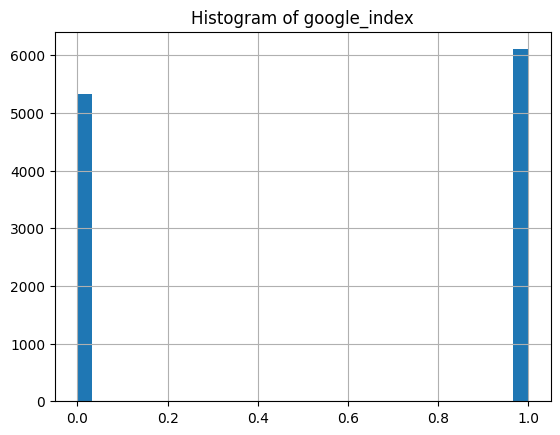

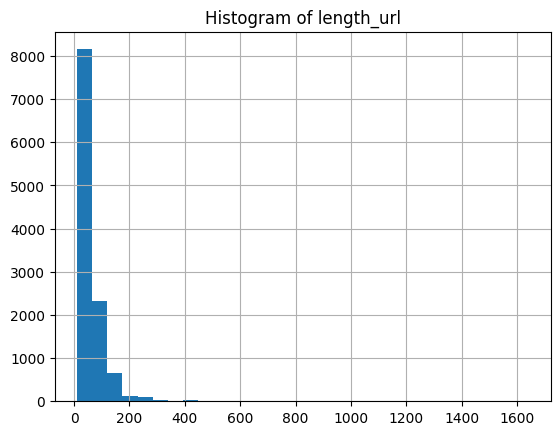

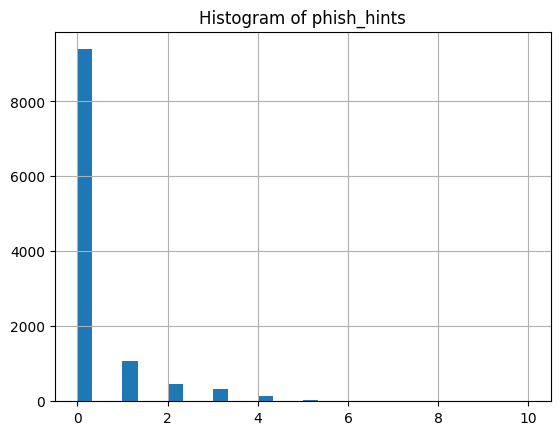

In [164]:
dataset1['google_index'].hist(bins=30)
plt.title('Histogram of google_index')
plt.show()

dataset1['length_url'].hist(bins=30)
plt.title('Histogram of length_url')
plt.show()

dataset1['phish_hints'].hist(bins=30)
plt.title('Histogram of phish_hints')
plt.show()

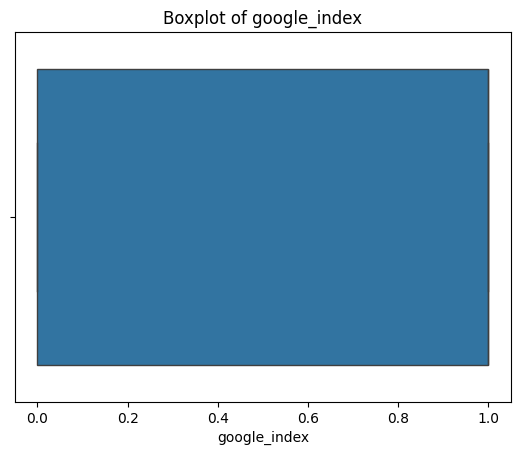

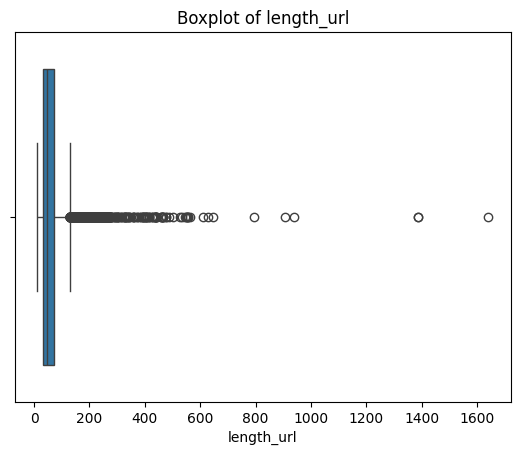

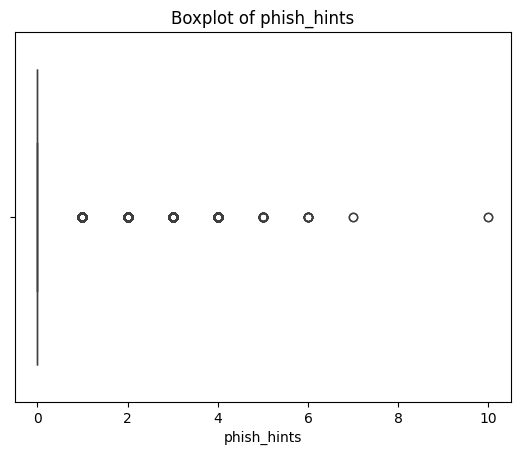

In [163]:
# Check for outliers
sns.boxplot(x=dataset1['google_index'])
plt.title('Boxplot of google_index')
plt.show()

sns.boxplot(x=dataset1['length_url'])
plt.title('Boxplot of length_url')
plt.show()

sns.boxplot(x=dataset1['phish_hints'])
plt.title('Boxplot of phish_hints')
plt.show()

**Conclusions:**

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

The data is usable, but not entirely what I expected.

Do you see any outliers? (Data points that are far from the rest of the data).

There are outliers present, as we can see in the boxplots and histograms. A good example is 'length_url'.

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

The first principal component captures only 15.72% of the total variance in the dataset, and the first two components combined capture 28.55%.

This indicates that PCA does not suggest a strong reduction in dimensionality for this dataset — most of the variance is spread across many components, and relying on just one or two principal components would result in a significant loss of information.

Therefore, while PCA can still be useful for visualization or understanding general patterns, a large number of components would be needed to adequately represent the dataset's full structure.

Try using your correlation information from previous weeks to help choose features for linear regression.

Based on the features more correlated with 'status', I chose to test linear regression with 'google_index', 'length_url', and 'phish_hints'. The high MSE in the linear model for 'length_url' evidences the presence of outliers.

In [165]:
# import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhajournal/phishingemails")

print("Path to dataset files:", path)

100%|██████████| 18.0M/18.0M [00:01<00:00, 15.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/subhajournal/phishingemails/versions/1


In [184]:
# import pandas as pd

# Load the dataset
dataset2 = pd.read_csv(path + '/Phishing_Email.csv')

# Display the first few rows of the dataset
print(dataset2.head())

   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


In [185]:
dataset2.nunique().sort_values(ascending=False)

,0
Unnamed: 0,18650
Email Text,17537
Email Type,2


In [186]:
# Drop rows with missing values
dataset2_cleaned = dataset2.dropna()

In [187]:
# Drop the 'Unnamed' column
dataset2_cleaned = dataset2_cleaned.drop(columns=['Unnamed: 0'])

In [188]:
dataset2_cleaned['Email Type'].value_counts()

,count
Email Type,
Safe Email,11322
Phishing Email,7312


In [175]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization to convert text data into numerical features
vectorizer = TfidfVectorizer(stop_words='english', max_features=100)  # You can adjust max_features if needed
X_tfidf = vectorizer.fit_transform(dataset2_cleaned['Email Text'])

# Convert the sparse matrix to a DataFrame
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

# Add the email type to the DataFrame
dataset2_encoded = dataset2_cleaned[['Email Type']].join(X_tfidf_df)

# Encode 'Email Type' as numeric (Safe Email = 0, Phishing Email = 1)
dataset2_encoded['Email Type'] = dataset2_encoded['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

# Display the resulting DataFrame
print(dataset2_encoded.head())

   Email Type   00  000   01        10  100   11        12   15  1998  ...  \
0           0  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.0   0.0  ...   
1           0  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.0   0.0  ...   
2           0  0.0  0.0  0.0  0.070144  0.0  0.0  0.163478  0.0   0.0  ...   
3           1  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.0   0.0  ...   
4           1  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.0   0.0  ...   

       use      want       way  web  work  workshop  world       www  year  \
0  0.56237  0.000000  0.312529  0.0   0.0       0.0    0.0  0.000000   0.0   
1  0.00000  0.000000  0.000000  0.0   0.0       0.0    0.0  0.000000   0.0   
2  0.00000  0.079865  0.000000  0.0   0.0       0.0    0.0  0.000000   0.0   
3  0.00000  0.000000  0.245110  0.0   0.0       0.0    0.0  0.188794   0.0   
4  0.00000  0.000000  0.000000  0.0   0.0       0.0    0.0  0.000000   0.0   

    ½ï  
0  0.0  
1  0.0  
2  0.0  
3  0.0  
4  0.0  

[5 rows

In [176]:
# Compute the correlation matrix
correlation_matrix = dataset2_encoded.corr()

# Display the correlation matrix
print(correlation_matrix)

            Email Type        00       000        01        10       100  \
Email Type    1.000000 -0.002457 -0.003683  0.000576  0.005521 -0.001182   
00           -0.002457  1.000000  0.054312  0.116836  0.164944  0.031585   
000          -0.003683  0.054312  1.000000 -0.003754  0.070056  0.069670   
01            0.000576  0.116836 -0.003754  1.000000  0.117646 -0.038038   
10            0.005521  0.164944  0.070056  0.117646  1.000000  0.012776   
...                ...       ...       ...       ...       ...       ...   
workshop     -0.000386  0.020458 -0.024118 -0.025296  0.018794 -0.020121   
world         0.010142  0.009399  0.016346 -0.027998 -0.004392  0.013828   
www          -0.008343  0.016406 -0.026424  0.045823  0.005374 -0.027640   
year         -0.007648 -0.003356  0.065124 -0.008727  0.025407  0.025962   
½ï           -0.004559 -0.006951 -0.007860 -0.008609 -0.012680 -0.004629   

                  11        12        15      1998  ...       use      want  \
Email Ty

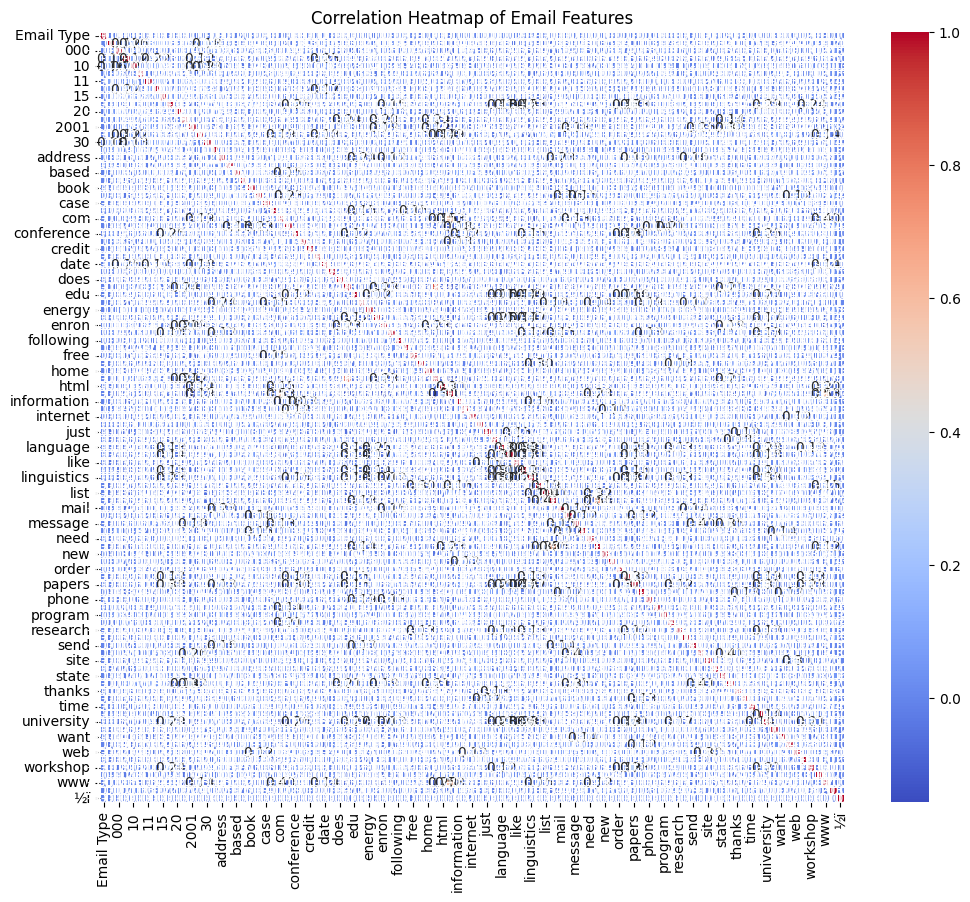

In [179]:
# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Email Features")
plt.show()

In [189]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Encode categorical data with .loc to avoid the warning
label_encoder = LabelEncoder()
dataset2_cleaned.loc[:, 'Email Type Encoded'] = label_encoder.fit_transform(dataset2_cleaned['Email Type'])

# Apply TF-IDF Vectorization with a limited vocabulary size
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Adjust the number of features as needed
email_text_tfidf = tfidf_vectorizer.fit_transform(dataset2_cleaned['Email Text'])

# Convert the TF-IDF matrix to a DataFrame
email_text_tfidf_df = pd.DataFrame(email_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Combine reduced TF-IDF features with other numerical columns
combined_df2 = pd.concat([dataset2_cleaned[['Email Type Encoded']], email_text_tfidf_df], axis=1)

# Calculate the correlation matrix
correlation_matrix = combined_df2.corr()

# Display the correlation matrix
print(correlation_matrix)

                    Email Type Encoded        00       000        01  \
Email Type Encoded            1.000000  0.002567  0.005868 -0.002831   
00                            0.002567  1.000000  0.043292  0.205273   
000                           0.005868  0.043292  1.000000  0.013547   
01                           -0.002831  0.205273  0.013547  1.000000   
02                            0.008021  0.001044  0.008461  0.072465   
...                                ...       ...       ...       ...   
york                          0.000616  0.002858 -0.003709 -0.013869   
you                           0.002462 -0.048987  0.053127 -0.106439   
your                         -0.002451 -0.037866  0.060704 -0.090690   
yourself                     -0.002469 -0.016036 -0.005803 -0.025962   
½ï                            0.005029 -0.004749 -0.005539 -0.008706   

                          02        03        04        05        06  \
Email Type Encoded  0.008021 -0.002396 -0.002832 -0.008034 -0.0

In [190]:
# Calculate the correlation matrix
correlation_matrix2 = combined_df2.corr()

# Set the threshold for correlations (positive or negative)
threshold = 0.8

# Create a mask for the correlation matrix to filter values greater than 0.8 or less than -0.8
highly_correlated_pairs2 = []

# Use a set to keep track of pairs to avoid duplicates
seen_pairs = set()

for column in correlation_matrix2.columns:
    # Get absolute correlations and identify pairs greater than the threshold (0.8 or -0.8)
    for index, value in correlation_matrix2[column].items():
        if abs(value) >= threshold and column != index:
            # Ensure pairs are in lexicographical order and check if already seen
            pair = tuple(sorted([column, index]))
            if pair not in seen_pairs:
                highly_correlated_pairs2.append((column, index, value))
                seen_pairs.add(pair)

# Convert the list to a DataFrame for easy viewing
highly_correlated_pairs_df2 = pd.DataFrame(highly_correlated_pairs2, columns=['Feature 1', 'Feature 2', 'Correlation'])

# Display the result
print(highly_correlated_pairs_df2)

  Feature 1    Feature 2  Correlation
0       ect          hou     0.915965
1        ie         ilug     0.891937
2        ie        linux     0.903090
3      ilug        linux     0.899466
4  listinfo      mailman     0.908061
5     lists  sourceforge     0.863331
6        sf  sourceforge     0.826388


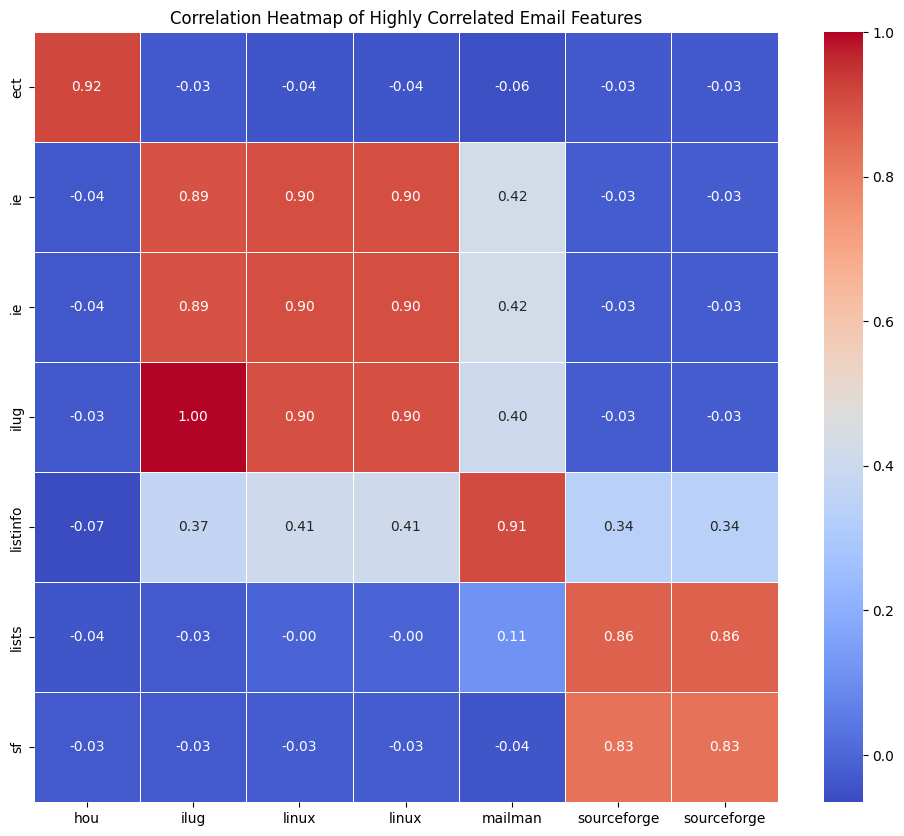

In [192]:
# Create a subset of the correlation matrix using the highly correlated pairs
highly_correlated_matrix2 = correlation_matrix2.loc[highly_correlated_pairs_df2['Feature 1'], highly_correlated_pairs_df2['Feature 2']]

# Plot heatmap using the subset of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(highly_correlated_matrix2, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)  # Use the subset matrix
plt.title("Correlation Heatmap of Highly Correlated Email Features")
plt.show()

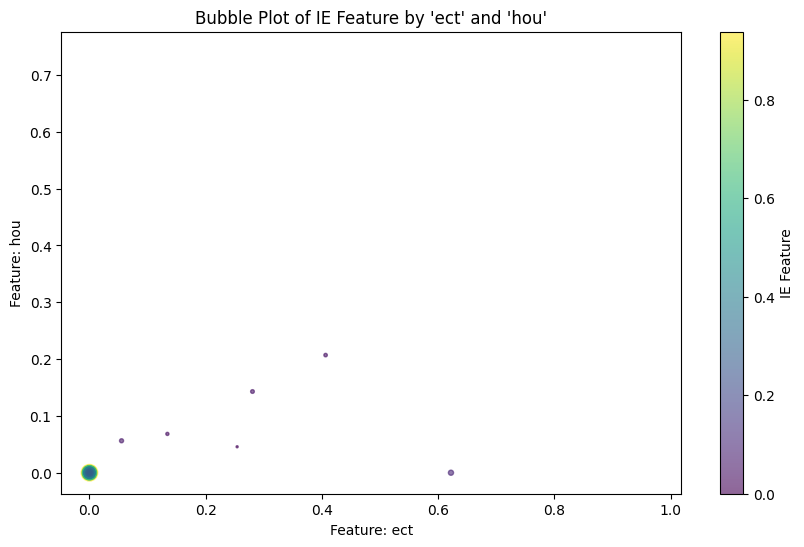

In [208]:
plt.figure(figsize=(10, 6))
scatter2 = plt.scatter(
    combined_df2["ect"],  # X-axis: Feature 'ect'
    combined_df2["hou"],  # Y-axis: Feature 'hou'
    s=combined_df2["ie"] * 150,  # Size bubbles based on 'ie' feature (scaled)
    c=combined_df2["ie"],  # Color bubbles by 'ie' feature
    cmap='viridis',  # Color map for 'ie' feature
    alpha=0.6  # Transparency of the bubbles
)

# Add color bar to represent 'ie' values
plt.colorbar(scatter2, label='IE Feature')

# Adding labels and title
plt.xlabel("Feature: ect")
plt.ylabel("Feature: hou")
plt.title("Bubble Plot of IE Feature by 'ect' and 'hou'")

# Show the plot
plt.show()


Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

**Conclusions:**

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [ ]:
# import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/exploring-cybersecurity-risk-via-2022-cisa-vulne")

print("Path to dataset files:", path)

In [ ]:
# import pandas as pd

# Load the dataset
dataset3_1 = pd.read_csv(path + '/2022-06-08-enriched.csv')
dataset3_2 = pd.read_csv(path + '/2022-06-09-enriched.csv')
dataset3_3 = pd.read_csv(path + '/2022-06-27-enriched.csv')
dataset3_4 = pd.read_csv(path + '/2022-07-04-enriched.csv')
dataset3_5 = pd.read_csv(path + '/2022-12-09-enriched.csv')


# Display the first few rows of the dataset
print(dataset3_1.head())

In [ ]:
# Concatenate DataFrames into one DataFrame
dataset3 = pd.concat([dataset3_1, dataset3_2, dataset3_3, dataset3_4, dataset3_5], ignore_index=True)

# Show the result as a DataFrame
print(dataset3)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
import matplotlib.pyplot as plt

# Data for the segments
segments = ['Segment 7', 'Segment 6', 'Segment 5', 'Segment 4', 'Segment 3', 'Segment 2', 'Segment 1']
us_population = [15, 32, 10, 10, 10, 7, 16]  # US Population percentages
our_customers = [11, 20, 17, 18, 15, 10, 9]  # Our Customers percentages

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the stacked bars for US Population
us_bottom = 0
for i, value in enumerate(us_population):
    # Set royalblue for Segments 5, 4, and 3, otherwise lightgrey
    color = 'royalblue' if segments[i] in ['Segment 5', 'Segment 4', 'Segment 3'] else 'lightgrey'
    ax.bar(0.5, value, bottom=us_bottom, color=color, edgecolor='whitesmoke')
    # Annotating each section inside the bar
    ax.text(0.5, us_bottom + value / 2, f'{value}%', ha='center', va='center', color='black', fontsize=12)
    us_bottom += value

# Plot the stacked bars for Our Customers
customers_bottom = 0
for i, value in enumerate(our_customers):
    # Set royalblue for Segments 5, 4, and 3, otherwise lightgrey
    color = 'royalblue' if segments[i] in ['Segment 5', 'Segment 4', 'Segment 3'] else 'lightgrey'
    ax.bar(1.5, value, bottom=customers_bottom, color=color, edgecolor='whitesmoke')
    # Annotating each section inside the bar
    ax.text(1.5, customers_bottom + value / 2, f'{value}%', ha='center', va='center', color='black', fontsize=12)
    customers_bottom += value

# Set the y-tick positions where we want the labels
y_positions = [sum(us_population[:i+1]) - value / 2 for i, value in enumerate(us_population)]

# Remove the default y-tick labels by setting empty labels
ax.set_yticks([])

# Manually add custom labels for segments
for i, segment in enumerate(segments[::-1]):
    # Apply royalblue and bold for segments 5, 4, and 3
    if segment in ['Segment 5', 'Segment 4', 'Segment 3']:
        ax.text(-0.1, y_positions[i], segment, ha='right', va='center', fontsize=12, fontweight='bold', color='royalblue')
    else:
        ax.text(-0.1, y_positions[i], segment, ha='right', va='center', fontsize=12)

# Hide ticks and borders
ax.set_xticks([])  # Hide x-axis ticks
ax.spines['top'].set_visible(False)  # Hide top border
ax.spines['right'].set_visible(False)  # Hide right border
ax.spines['left'].set_visible(False)  # Hide left border

# Set labels and title
ax.set_xticks([0.5, 1.5])  # X positions for the two bars
ax.set_xticklabels(['US Population', 'Our Customers'])
ax.set_title('Distribution by Customer Segment', fontsize=14, ha='right', x=0.22)

# Adjust layout for better readability
plt.tight_layout()
plt.show()

**FIGURE 5.13** Aesthetic design